In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.datasets import make_blobs

In [2]:
X,y = make_blobs(n_samples=1000, n_features=2, centers=3, random_state=23)

In [4]:
X.shape

(1000, 2)

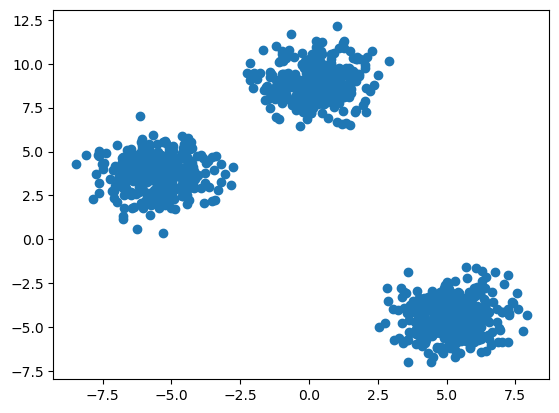

In [5]:
plt.scatter(X[:,0], X[:,1])

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=32)

In [7]:
from sklearn.cluster import KMeans

In [8]:
#Manual Process

wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k, init='k-means++')
    kmeans.fit(X_train)
    wcss.append(kmeans.inertia_)

wcss

[40951.10935637731,
 9737.461822042653,
 1608.2554422508788,
 1415.1170176656449,
 1233.057835733294,
 1117.155273748115,
 947.3406813606866,
 813.940119911945,
 762.0276624200555,
 703.2635072483088]

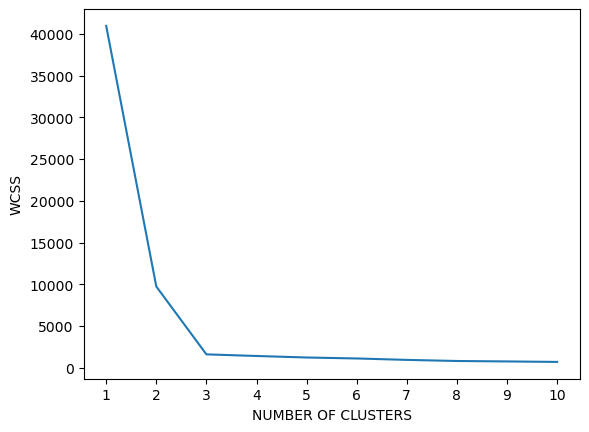

In [10]:
plt.plot(range(1,11), wcss)
plt.xticks(range(1,11))
plt.xlabel("NUMBER OF CLUSTERS")
plt.ylabel("WCSS")
plt.show()

In [11]:
kmeans = KMeans(n_clusters = 3, init='k-means++')
label = kmeans.fit_predict(X_train)

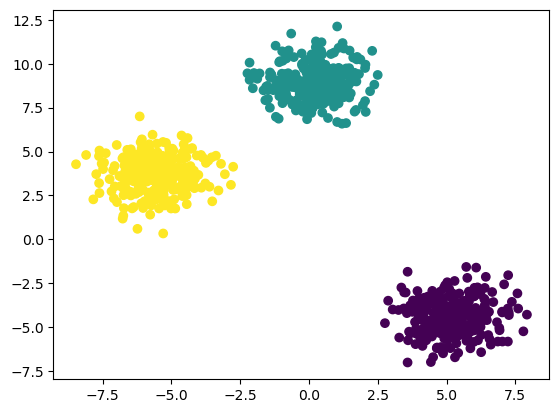

In [13]:
plt.scatter(X_train[:,0], X_train[:,1], c=label)

In [14]:
!pip install kneed

In [16]:
from kneed import KneeLocator
kl = KneeLocator(range(1,11), wcss, curve='convex', direction='decreasing')
print(kl.elbow)

3


In [21]:
from sklearn.metrics import silhouette_score

silhouette_coefficient = []
for k in range(2,11):
    kmeans = KMeans(n_clusters=k, init='k-means++')
    kmeans.fit(X_train)
    score = silhouette_score(X_train,kmeans.labels_)
    silhouette_coefficient.append(score)

In [22]:
silhouette_coefficient

[0.7224127308085881,
 0.80320363980216,
 0.6363696075319257,
 0.6380301789641939,
 0.32946615614356317,
 0.5183668606992866,
 0.33053701249692297,
 0.34384061227451823,
 0.34781656205640443]

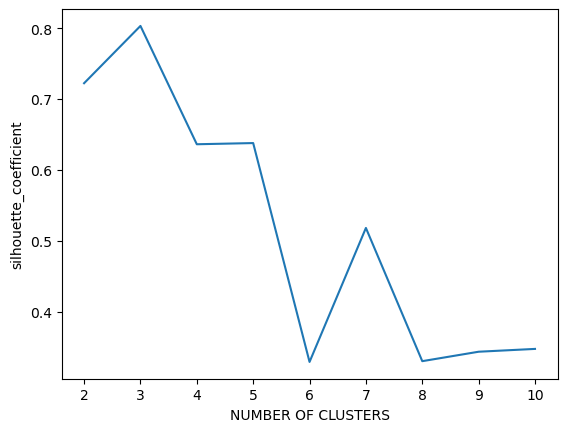

In [23]:
plt.plot(range(2,11), silhouette_coefficient)
plt.xticks(range(2,11))
plt.xlabel("NUMBER OF CLUSTERS")
plt.ylabel("silhouette_coefficient")
plt.show()